1. Đọc và phân tích cấu hình data.yaml
Kiểm tra xem dataset Roboflow định nghĩa những class nào và số lượng bao nhiêu.

In [1]:
import yaml

yaml_path = "../data/ppe-5/data.yaml"  # Chỉnh lại đường dẫn đúng
with open(yaml_path, "r") as f:
    data_config = yaml.safe_load(f)

print("📌 Chi tiết cấu hình Data:")
print(f"- Số lượng Classes (nc): {data_config.get('nc')}")
print(f"- Tên các Classes (names): {data_config.get('names')}")

📌 Chi tiết cấu hình Data:
- Số lượng Classes (nc): 8
- Tên các Classes (names): ['boots', 'helmet', 'helmet on', 'no boots', 'no helmet', 'no vest', 'person', 'vest']


2. Thống kê phân bố số lượng nhãn (Class Distribution Check)
Mục tiêu: Kiểm tra xem các lớp có bị mất cân bằng (imbalanced) hay không? (Ví dụ: Số lượng Helmet quá nhiều nhưng NO-Helmet quá ít sẽ làm mô hình học lệch).

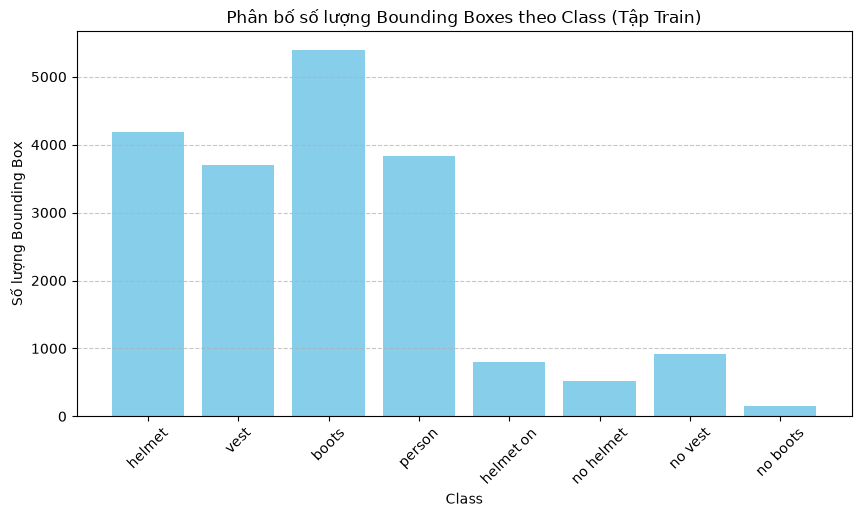

In [2]:
import os
from collections import Counter
import matplotlib.pyplot as plt

def count_classes(labels_dir, class_names):
    class_counts = Counter()
    for label_file in os.listdir(labels_dir):
        if label_file.endswith('.txt'):
            with open(os.path.join(labels_dir, label_file), 'r') as f:
                for line in f:
                    parts = line.strip().split()
                    if parts:
                        class_id = int(parts[0])
                        class_counts[class_names[class_id]] += 1
    return class_counts

# Đếm trên tập Train
train_labels_dir = "../data/ppe-5/train/labels"
class_names = data_config['names']
counts = count_classes(train_labels_dir, class_names)

# Trực quan hóa bằng biểu đồ cột
plt.figure(figsize=(10, 5))
plt.bar(counts.keys(), counts.values(), color='skyblue')
plt.title("Phân bố số lượng Bounding Boxes theo Class (Tập Train)")
plt.xlabel("Class")
plt.ylabel("Số lượng Bounding Box")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

3. Trực quan hóa Bounding Box lên ảnh gốc (Sanity Check / Visualization)
Mục tiêu: Tự tay vẽ Bounding Box từ file .txt lên ảnh xem Roboflow gán nhãn có bị lệch/lỗi không và hiểu tọa độ YOLO ($x_{center}, y_{center}, w, h$ normalized) hoạt động như thế nào.

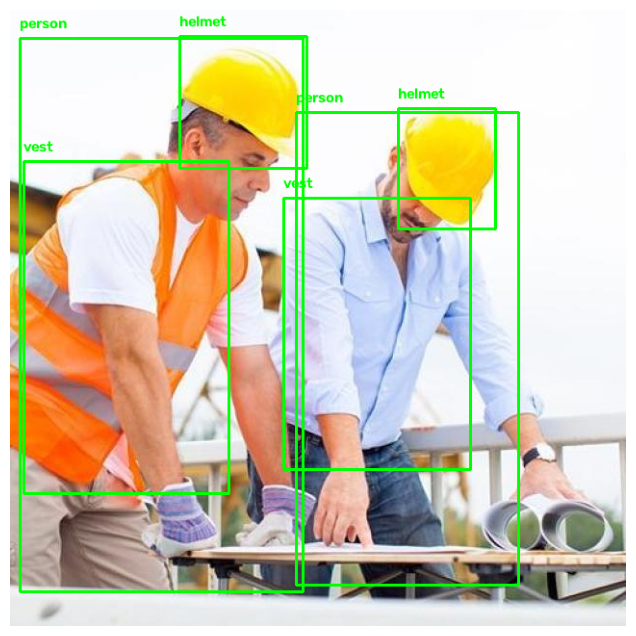

In [3]:
import cv2
import glob
import random

def draw_boxes(img_path, label_path, class_names):
    img = cv2.imread(img_path)
    h, w, _ = img.shape
    
    if os.path.exists(label_path):
        with open(label_path, 'r') as f:
            for line in f:
                class_id, x_c, y_c, bw, bh = map(float, line.strip().split())
                # Chuyển đổi tọa độ từ Normalized sang Pixel thực tế
                x1 = int((x_c - bw / 2) * w)
                y1 = int((y_c - bh / 2) * h)
                x2 = int((x_c + bw / 2) * w)
                y2 = int((y_c + bh / 2) * h)
                
                # Vẽ khung & viết tên Class
                label_name = class_names[int(class_id)]
                cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
                cv2.putText(img, label_name, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)
                
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Lấy ngẫu nhiên 1 ảnh kiểm tra
img_list = glob.glob("../data/ppe-5/train/images/*")
random_img_path = random.choice(img_list)
random_label_path = random_img_path.replace("images", "labels").rsplit('.', 1)[0] + ".txt"

plt.figure(figsize=(8, 8))
plt.imshow(draw_boxes(random_img_path, random_label_path, class_names))
plt.axis('off')
plt.show()

4. Kiểm tra kích thước Bounding Box (Box Size Analysis)

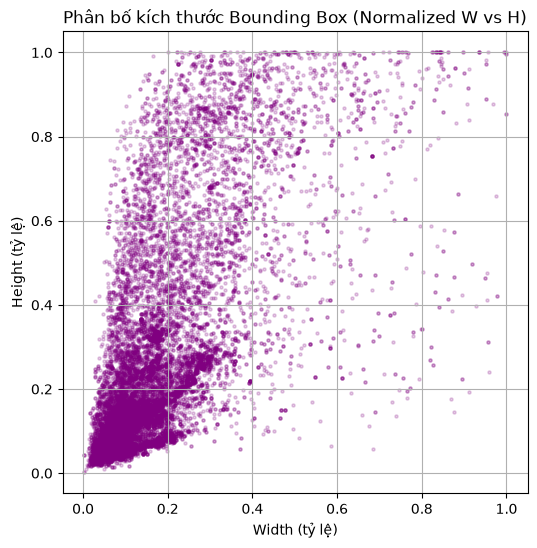

In [4]:
# Code gợi ý kiểm tra chiều rộng & chiều cao tương đối của các box
import os
import matplotlib.pyplot as plt

widths, heights = [], []
labels_dir = "../data/ppe-5/train/labels"

for label_file in os.listdir(labels_dir):
    if label_file.endswith('.txt'):
        with open(os.path.join(labels_dir, label_file), 'r') as f:
            for line in f:
                parts = line.strip().split()
                if parts:
                    widths.append(float(parts[3]))   # width normalized
                    heights.append(float(parts[4]))  # height normalized

plt.figure(figsize=(6, 6))
plt.scatter(widths, heights, alpha=0.2, s=5, color='purple')
plt.title("Phân bố kích thước Bounding Box (Normalized W vs H)")
plt.xlabel("Width (tỷ lệ)")
plt.ylabel("Height (tỷ lệ)")
plt.grid(True)
plt.show()